## AdaBoosting


AdaBoost (Adaptive Boosting) operates on the principle that many "weak" learners (models that perform only slightly better than random guessing) can be combined to form a single "strong" learner. It does this sequentially: each new weak learner is forced to focus on the training samples that the previous learners misclassified.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
n_samples = 200
X = np.random.randn(n_samples, 2)
y = np.where(X[:, 0] + X[:, 1] > 0, 1, -1)
noise_indices = np.random.choice(np.arange(n_samples), int(n_samples * 0.1), replace=False)
y[noise_indices] = -y[noise_indices]

In [4]:
# Split data into train and test sets (80/20)
split_idx = int(0.8 * n_samples)
X_train, y_train = X[:split_idx], y[:split_idx]
X_test, y_test = X[split_idx:], y[split_idx:]

In [5]:
class DecisionStump:
    def __init__(self):
        self.polarity = 1
        self.feature_index = None
        self.threshold = None
        self.alpha = None

    def predict(self, X):
        n_samples = X.shape[0]
        X_column = X[:, self.feature_index]
        predictions = np.ones(n_samples)

        if self.polarity == 1:
            predictions[X_column < self.threshold] = -1
        else:
            predictions[X_column > self.threshold] = -1

        return predictions

In [52]:
class AdaBoost:
    def __init__(self, n_clf=50):
      self.n_clf = n_clf
      self.clfs = []

    def fit(self, X, y):
      n_samples, n_features = X.shape

      # Initialize weights to 1/N
      w = np.full(n_samples, (1 / n_samples))

      for _ in range(self.n_clf):
        clf = DecisionStump()
        min_error = float('inf')

        for feature_i in range(n_features):
          X_column = X[:, feature_i]
          thresholds = np.unique(X_column)

          for threshold in thresholds:
            p = 1
            predictions = np.ones(n_samples)
            predictions[X_column < threshold] = -1

            misclassified = w[y != predictions]
            error = sum(misclassified)

            if error > 0.5:
              error = 1 - error
              p = -1

            if error < min_error:
              clf.polarity = p
              clf.threshold = threshold
              clf.feature_index = feature_i
              min_error = error

        EPS = 1e-10
        clf.alpha = 0.5 * np.log((1.0 - min_error + EPS) / (min_error + EPS))

        predictions = clf.predict(X)

        w *= np.exp(-clf.alpha * y * predictions)
        w /= np.sum(w)

        self.clfs.append(clf)

    def predict(self, X):
      clf_preds = [clf.alpha * clf.predict(X) for clf in self.clfs]
      y_pred = np.sum(clf_preds, axis=0)
      return np.sign(y_pred)

    def weights(self):
      return [clf.alpha for clf in self.clfs]

In [16]:
clf = AdaBoost(n_clf=10)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = np.sum(y_pred == y_test) / len(y_test)
print("Accuracy:", accuracy)

Accuracy: 0.75


Visualizing first 3 weak learners (decision stumps) and the final AdaBoost classifier:


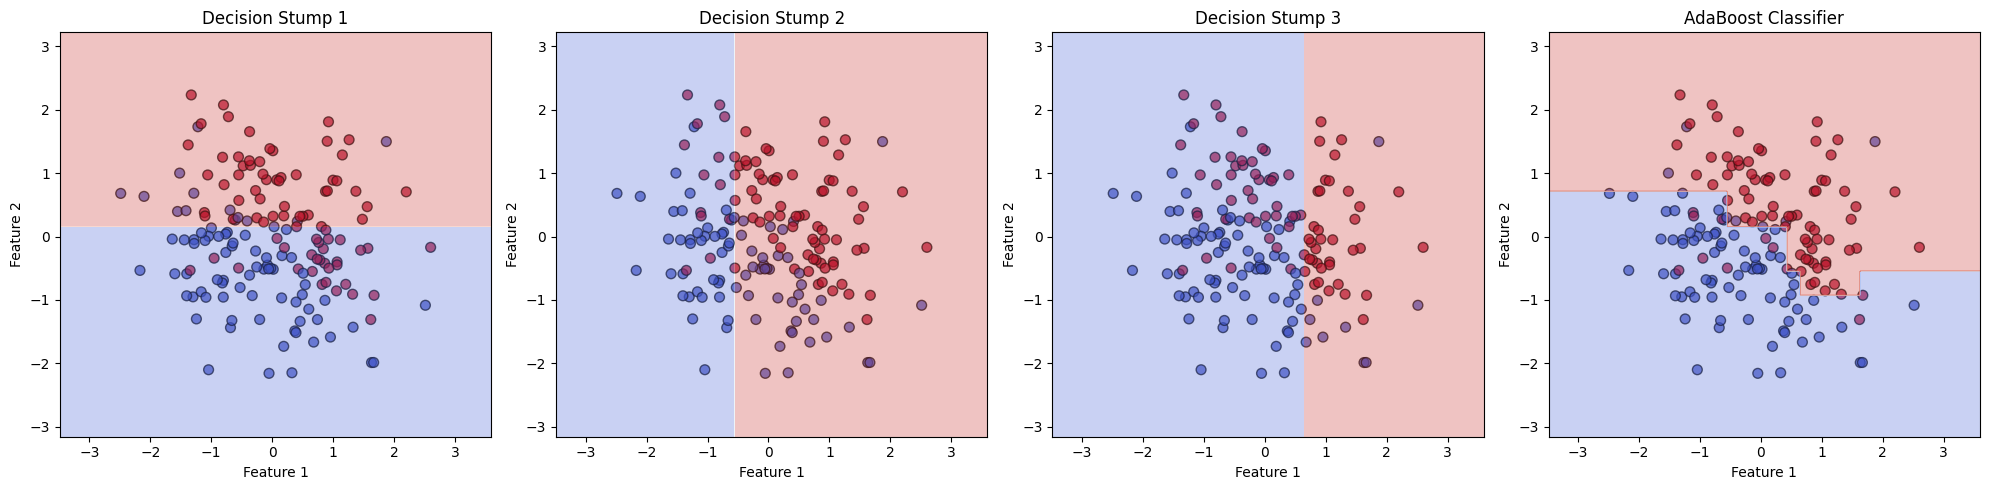

In [35]:
def plot_decision_boundary(clf, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                           np.arange(y_min, y_max, 0.02))

    # Plot training points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k', alpha=0.7)

    # Plot the decision boundary
    if isinstance(clf, DecisionStump):
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    else: # AdaBoost classifier
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')


# Visualize a few individual decision stumps and the final AdaBoost classifier

# Create a figure with a grid of subplots (e.g., 1 row, 4 columns for 3 stumps + 1 final)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

print("Visualizing first 3 weak learners (decision stumps) and the final AdaBoost classifier:")
for i, stump in enumerate(clf.clfs[:3]): # Plotting first 3 stumps
    plot_decision_boundary(stump, X_train, y_train, f'Decision Stump {i+1}', axes[i])

# Plot the final AdaBoost classifier decision boundary in the last subplot
plot_decision_boundary(clf, X_train, y_train, 'AdaBoost Classifier', axes[3])

plt.tight_layout()
plt.show()

In [63]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators=10, learning_rate=1.0)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
accuracy = np.sum(y_pred == y_test) / len(y_test)
print("Accuracy:", accuracy)

Accuracy: 0.725


In [64]:
ada.estimator_weights_

array([1.00097382, 1.1063128 , 0.68453248, 0.93795244, 0.62968653,
       0.6416733 , 0.39049428, 0.22123389, 0.26084635, 0.23061742])

## Adaptive Boosting Scratch

In [71]:
df = pd.DataFrame()
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['y'] = [1,1,0,1,0,1,0,1,0,0]
df

,X1,X2,y
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


In [72]:
from sklearn.tree import DecisionTreeClassifier

In [185]:
class AdaBoostClassification:
    def __init__(self, n_clf=50):
      self.n_clf = n_clf
      self.clfs = []

    def fit(self, X, y):
      n_samples, n_features = X.shape

      # Convert 0s to -1s for AdaBoost algorithm compatibility
      y_converted = np.where(y == 0, -1, y)

      # Initialize weights to 1/N
      w = np.full(n_samples, (1 / n_samples))

      for _ in range(self.n_clf):
        clf = DecisionTreeClassifier(max_depth=1)
        clf.fit(X, y_converted, sample_weight=w) # Use converted y here
        predictions = clf.predict(X)

        # Ensure predictions are also in -1, 1 format for error calculation
        predictions = np.where(predictions == 0, -1, predictions)

        # Calculate error
        misclassified = w[y_converted != predictions]
        error = sum(misclassified)
        alpha = 0.5 * np.log((1.0 - error) / error)

        # Update weights
        w *= np.exp(-alpha * y_converted * predictions) # Use converted y here
        w /= np.sum(w)

        self.clfs.append((clf, alpha))

    def predict(self, X):
      clf_preds = [clf.predict(X) * alpha for clf, alpha in self.clfs]
      y_pred = np.sum(clf_preds, axis=0)
      # Convert -1 to 0 in the final prediction output and cast to integer type
      return np.where(np.sign(y_pred) == -1, 0, np.sign(y_pred)).astype(np.int64)

In [181]:
clf2 = AdaBoostClassification(n_clf=10)
clf2.fit(df.iloc[:,:2], df.iloc[:,-1])

In [182]:
y_pred = clf2.predict(df.iloc[:,:2])
y_pred

array([1, 1, 0, 1, 0, 1, 0, 1, 0, 0])

In [183]:
ada2 = AdaBoostClassifier(n_estimators=10, learning_rate=1.0)
ada2.fit(df.iloc[:,:2], df.iloc[:,-1])

AdaBoostClassifier(n_estimators=10)

In [184]:
y_pred2 = ada2.predict(df.iloc[:,:2])
y_pred2

array([1, 1, 0, 1, 0, 1, 0, 1, 0, 0])